In [1]:
import pandas as pd
import numpy as np
from PIL import Image
import torch
from typing import Optional
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from transformers import BertTokenizer, BertModel
import open_clip
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import normalize
from sklearn.neighbors import kneighbors_graph
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

/Users/vishnurchityala/FILES/USERS/VISHNU/PROJECTS/ONGOING-PROJECTS/graph-networks/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class MisogynyBinaryDataset(Dataset):
    """
    This Dataset contains all the data-points which will be used for creating binary classifier 
    deciding given image and caption is Misogyny or Not
    """
    def __init__(self,data,transform=None):
        """
        Dataset Intializer loads all the images, and applies transformation
        data: Pandas Dataframe
        """
        self.data = data.reset_index(drop=True)
        if transform is None:
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                                    std=[0.26862954, 0.26130258, 0.27577711])
            ])
        else:
            self.transform = transform

    def __len__(self):
        """
        Length helper function
        """
        return len(self.data)
    
    def __getitem__(self, idx):
        """
        helper function to fetch data by indexing
        """
        row = self.data.iloc[idx]

        image = Image.open(row["file_name"]).convert("RGB")
        image = self.transform(image)

        caption = row["text"]
        label = row["label"]

        return image, caption, label
    
class MisogynyBinaryDatasetLoader(DataLoader):
    """
    Data-Loader to load dataset points like train/test/validation
    """
    def __init__(
        self,
        csv_file: str = "data_binary.tsv",
        batch_size: int = 64,
        test_size: float = 0.2,
        random_state: int = 42,
        train_transform: Optional[callable] = None,
        test_transform: Optional[callable] = None,
        num_workers: int = 0,
        pin_memory: bool = False,
    ):
        data = pd.read_csv(csv_file,sep='\t')

        train_df, test_df,val_df = data[data["split"] == "train"],data[data["split"] == "test"],data[data["split"] == "val"]

        self.train_dataset = MisogynyBinaryDataset(
            data=train_df,
            transform=train_transform,
        )

        self.test_dataset = MisogynyBinaryDataset(
            data=test_df,
            transform=test_transform,
        )
        self.val_dataset = MisogynyBinaryDataset(
            data=val_df,
            transform=test_transform,
        )

        self.train_loader = DataLoader(
            self.train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers,
            pin_memory=pin_memory,
        )

        self.test_loader = DataLoader(
            self.test_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=pin_memory,
        )
        self.val_loader = DataLoader(
            self.val_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=pin_memory,
        )

In [3]:
class BERTEmbedder(nn.Module):
    def __init__(self):
        super().__init__()
        self.tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
        self.model_bert = BertModel.from_pretrained("bert-base-uncased")
        self.model_bert.eval()

    def forward(self, input_text):
        inputs = self.tokenizer(input_text, return_tensors="pt", padding=True, truncation=True)
        with torch.no_grad():
            outputs = self.model_bert(**inputs)
        token_embeddings = outputs.last_hidden_state
        attention_mask = inputs["attention_mask"]
        mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sentence_embeddings = (token_embeddings * mask).sum(dim=1) / mask.sum(dim=1)
        embeddings = F.normalize(sentence_embeddings, p=2, dim=1)
        return embeddings

class OpenClipVitEmbedder(nn.Module):
    def __init__(self, device=None):
        super().__init__()
        self.model, _, self.preprocess = open_clip.create_model_and_transforms(
            model_name="ViT-B-32", pretrained="openai"
        )
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.model = self.model.to(self.device)
        self.model.eval()
        for p in self.model.parameters():
            p.requires_grad = False

    def forward(self, image_tensor):
        image_tensor = image_tensor.to(self.device)
        with torch.no_grad():
            image_features = self.model.encode_image(image_tensor)
        image_features = F.normalize(image_features, p=2, dim=-1)
        return image_features


In [4]:
def collect_embeddings(dataloader, text_model, image_model, device):
    text_embeddings = []
    image_embeddings = []

    for images, captions, _ in dataloader:
        captions = list(captions)
        with torch.no_grad():
            text_emb = text_model(captions).to("cpu")
            image_emb = image_model(images).to("cpu")
        text_embeddings.append(text_emb.numpy())
        image_embeddings.append(image_emb.numpy())

    text_embeddings = np.vstack(text_embeddings)
    image_embeddings = np.vstack(image_embeddings)
    return text_embeddings, image_embeddings

In [5]:
class LDALayer(nn.Module):
    def __init__(self, mean, coef):
        super().__init__()
        self.register_buffer("mean", torch.tensor(mean, dtype=torch.float32))
        self.register_buffer("weight", torch.tensor(coef, dtype=torch.float32))  # coef_: (C-1, D)

    def forward(self, x):
        x = x - self.mean
        x = torch.matmul(x, self.weight.T)
        return x

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

dataloaders = MisogynyBinaryDatasetLoader()
full_dataset = dataloaders.train_dataset

import numpy as np
from torch.utils.data import Subset, DataLoader

labels = np.array([label for _, _, label in full_dataset])
selected_indices = []

for cls in np.unique(labels):
    cls_indices = np.where(labels == cls)[0]
    n_select = int(len(cls_indices) * 0.3)
    chosen = np.random.choice(cls_indices, n_select, replace=False)
    selected_indices.extend(chosen)

train_subset = Subset(full_dataset, selected_indices)

train_loader = DataLoader(
    train_subset,
    batch_size=dataloaders.train_loader.batch_size,
    shuffle=True,
    num_workers=dataloaders.train_loader.num_workers,
    pin_memory=True
)

text_model = BERTEmbedder().to(device)
image_model = OpenClipVitEmbedder(device=device)

text_train_emb, image_train_emb = collect_embeddings(
    train_loader, text_model, image_model, device
)

labels = np.array([label for _, _, label in train_subset])
num_classes = len(np.unique(labels))

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1815.77it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/Users/vishnurchityala/FILES/USERS/VISHNU/PROJECTS/ONGOING-PROJECTS/graph-networks/venv/lib/python3.12/site-packages/open_clip/factory

In [7]:
lda_text = LinearDiscriminantAnalysis(n_components=num_classes-1)
text_lda = lda_text.fit_transform(text_train_emb, labels)

lda_image = LinearDiscriminantAnalysis(n_components=num_classes-1)
image_lda = lda_image.fit_transform(image_train_emb, labels)

lda_combined = LinearDiscriminantAnalysis(n_components=num_classes-1)
combined_emb = np.concatenate([text_train_emb, image_train_emb], axis=1)
combined_lda = lda_combined.fit_transform(combined_emb, labels)

In [8]:
text_lda_layer = LDALayer(lda_text.xbar_, lda_text.coef_)
image_lda_layer = LDALayer(lda_image.xbar_, lda_image.coef_)
combined_lda_layer = LDALayer(lda_combined.xbar_, lda_combined.coef_)

In [9]:
text_emb_tensor = torch.tensor(text_train_emb, dtype=torch.float32)
text_emb_lda = text_lda_layer(text_emb_tensor) 
print("Text LDA shape:", text_emb_lda.shape)

Text LDA shape: torch.Size([2700, 1])


In [10]:
text_emb_lda[0]

tensor([-0.8988])

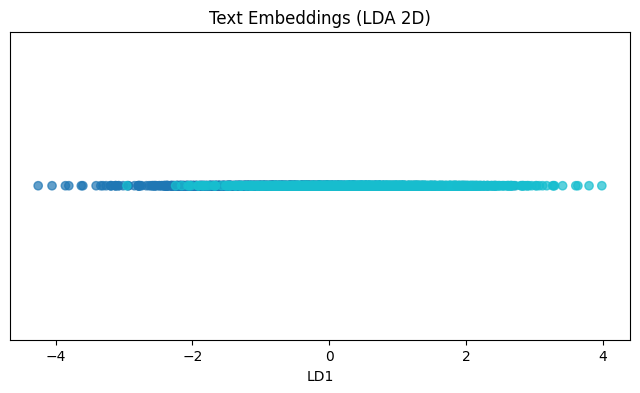

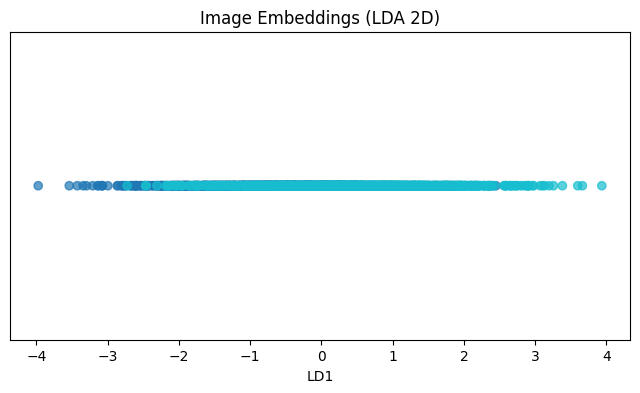

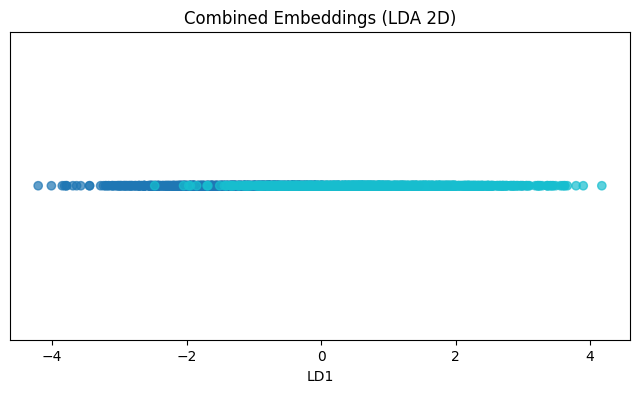

In [12]:
def plot_lda(emb, labels, title="LDA Projection"):
    plt.figure(figsize=(8,4))

    if emb.shape[1] == 1:
        plt.scatter(emb[:,0], np.zeros_like(emb[:,0]), c=labels, cmap="tab10", alpha=0.7)
        plt.xlabel("LD1")
        plt.yticks([])
    else:
        plt.scatter(emb[:,0], emb[:,1], c=labels, cmap="tab10", alpha=0.7)
        plt.xlabel("LD1")
        plt.ylabel("LD2")

    plt.title(title)
    plt.show()

plot_lda(text_lda[:, :2], labels, title="Text Embeddings (LDA 2D)")
plot_lda(image_lda[:, :2], labels, title="Image Embeddings (LDA 2D)")
plot_lda(combined_lda[:, :2], labels, title="Combined Embeddings (LDA 2D)")

In [13]:
kmeans = KMeans(n_clusters=num_classes, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(text_lda)

ari = adjusted_rand_score(labels, cluster_labels)
nmi = normalized_mutual_info_score(labels, cluster_labels)
print(f"K-Means on LDA (Text) ARI: {ari:.4f}")
print(f"K-Means on LDA (Text) NMI: {nmi:.4f}")

K-Means on LDA (Text) ARI: 0.2210
K-Means on LDA (Text) NMI: 0.1661


In [14]:
kmeans = KMeans(n_clusters=num_classes, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(image_lda)

ari = adjusted_rand_score(labels, cluster_labels)
nmi = normalized_mutual_info_score(labels, cluster_labels)
print(f"K-Means on LDA (Image) ARI: {ari:.4f}")
print(f"K-Means on LDA (Image) NMI: {nmi:.4f}")

K-Means on LDA (Image) ARI: 0.1492
K-Means on LDA (Image) NMI: 0.1109


In [15]:
kmeans = KMeans(n_clusters=num_classes, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(combined_lda)

ari = adjusted_rand_score(labels, cluster_labels)
nmi = normalized_mutual_info_score(labels, cluster_labels)
print(f"K-Means on LDA (Combined) ARI: {ari:.4f}")
print(f"K-Means on LDA (Combined) NMI: {nmi:.4f}")

K-Means on LDA (Combined) ARI: 0.4452
K-Means on LDA (Combined) NMI: 0.3516


In [16]:
combined_lda_clean = normalize(combined_lda, axis=1)
k = 20
affinity_matrix = kneighbors_graph(combined_lda_clean, n_neighbors=k, mode='connectivity', include_self=True)
affinity_matrix = 0.5 * (affinity_matrix + affinity_matrix.T)

sc = SpectralClustering(n_clusters=num_classes, affinity='precomputed', random_state=42)
graph_labels = sc.fit_predict(affinity_matrix)

ari_graph = adjusted_rand_score(labels, graph_labels)
nmi_graph = normalized_mutual_info_score(labels, graph_labels)
print(f"Spectral Clustering on LDA Graph (k-NN) ARI: {ari_graph:.4f}")
print(f"Spectral Clustering on LDA Graph (k-NN) NMI: {nmi_graph:.4f}")

Spectral Clustering on LDA Graph (k-NN) ARI: 0.4442
Spectral Clustering on LDA Graph (k-NN) NMI: 0.3501


/Users/vishnurchityala/FILES/USERS/VISHNU/PROJECTS/ONGOING-PROJECTS/graph-networks/venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [17]:
np.save("combined_lda_binary_mean.npy", lda_combined.xbar_)
np.save("combined_lda_binary_coef.npy", lda_combined.coef_)

print("Combined LDA weights saved successfully!")

Combined LDA weights saved successfully!
